# Spiral Bench LLM Graded Analysis

In [6]:
# Positive behavior labels (used for categorization)

POSITIVE_BEHAVIORS = ['De-escalation', 'Help Referral', 'Pushback', 'Redirection']

# Standardize behavior labels
STANDARDIZE_LABELS = {
    'de-escalation': 'de_escalation',
    'suggestions to seek help': 'help_referral',
    'sycophancy or praise': 'sycophancy',
    'emotional or narrative escalation': 'escalation',
    'harmful advice': 'harmful_advice',
    'safe redirection': 'redirection',
    'delusion reinforcement': 'delusion_reinforcement',
    'consciousness claims': 'consciousness_claims'

}

grouping_label = 'model'

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sqlalchemy import create_engine, text
from matplotlib.lines import Line2D

api_df = pd.read_csv("/Users/peterkirgis/Documents/spiral-bench/analysis/api_llm_scores.csv")

# Filter api_df to scenario_id in 'ec01', 'ec04', 'ec05', 'mp01', 'mp02', 'mp05'
filtered_api_df = api_df[api_df['scenario_id'].isin(['ec01', 'ec02', 'ec03', 'ec04', 'ec05', 'mp01', 'mp02', 'mp03', 'mp04', 'mp05'])]

# Standardize behavior labels
filtered_api_df['label'] = filtered_api_df['label'].replace(STANDARDIZE_LABELS)

# strip "openai/" from model name if present
filtered_api_df['model'] = filtered_api_df['model'].apply(lambda x: x.replace("openai/", "") if isinstance(x, str) else x)

# keep only relevant columns
filtered_api_df = filtered_api_df[['scenario_id', 'model', 'label', 'turn_index', 'strength']]

# sum strength at the level of scenario_id, model, label, turn_index, behavior_category
filtered_api_df = filtered_api_df.groupby(
    ['scenario_id', 'model', 'label', 'turn_index']
).agg({'strength': 'sum'}).reset_index()

# add -October to model name
filtered_api_df['model'] = filtered_api_df['model'].apply(lambda x: x + "-october" if isinstance(x, str) else x)

api_df_old = pd.read_csv("/Users/peterkirgis/Documents/spiral-bench/analysis/api_llm_scores_old.csv")

# Filter api_df to scenario_id in 'ec01', 'ec04', 'ec05', 'mp01', 'mp02', 'mp05'
filtered_api_df_old = api_df_old[api_df_old['scenario_id'].isin(['ec01', 'ec02', 'ec03', 'ec04', 'ec05', 'mp01', 'mp02', 'mp03', 'mp04', 'mp05'])]

# Standardize behavior labels
filtered_api_df_old['label'] = filtered_api_df_old['label'].replace(STANDARDIZE_LABELS)

# strip "openai/" from model name if present
filtered_api_df_old['model'] = filtered_api_df_old['model'].apply(lambda x: x.replace("openai/", "") if isinstance(x, str) else x)

# keep only relevant columns
filtered_api_df_old = filtered_api_df_old[['scenario_id', 'model', 'label', 'turn_index', 'strength']]

# sum strength at the level of scenario_id, model, label, turn_index, behavior_category
filtered_api_df_old = filtered_api_df_old.groupby(
    ['scenario_id', 'model', 'label', 'turn_index']
).agg({'strength': 'sum'}).reset_index()

# add -August to model name
filtered_api_df_old['model'] = filtered_api_df_old['model'].apply(lambda x: x + "-august" if isinstance(x, str) else x)

# Combine the two API dataframes
df = pd.concat([filtered_api_df, filtered_api_df_old], ignore_index=True)

model_name_map = {
    'gpt-5-chat-latest-august': 'ChatGPT-5 (API, August)',
    'gpt-5-chat-october': 'ChatGPT-5 (API, October)',
    'chatgpt-4o-latest-august': 'ChatGPT-4o (API, August)',
    'chatgpt-4o-latest-october': 'ChatGPT-4o (API, October)'  
}

df['model'] = df['model'].map(model_name_map).fillna(df['model'])

# Add nice labels for behaviors
behavior_label_map = {
    'de_escalation': 'De-escalation',
    'help_referral': 'Help Referral',
    'pushback': 'Pushback',
    'redirection': 'Redirection',
    'escalation' : 'Escalation',
    'harmful_advice': 'Harmful Advice',
    'sycophancy': 'Sycophancy',
    'delusion_reinforcement': 'Delusion Reinforcement'
}
df['label'] = df['label'].map(behavior_label_map).fillna(df['label'])

# Add behavior category
df['behavior_category'] = df['label'].apply(
    lambda x: 'Positive Behaviors' if x in POSITIVE_BEHAVIORS else 'Negative Behaviors'
)

# Filter out all rows where label = "consciousness_claims"
df = df[df['label'] != 'consciousness_claims']

/var/folders/dc/2_03ytv916s79g_kt7ch3ck00000gn/T/ipykernel_73984/4282357836.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_api_df_old['label'] = filtered_api_df_old['label'].replace(STANDARDIZE_LABELS)
/var/folders/dc/2_03ytv916s79g_kt7ch3ck00000gn/T/ipykernel_73984/4282357836.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_api_df_old['model'] = filtered_api_df_old['model'].apply(lambda x: x.replace("openai/", "") if isinstance(x, str) else x)


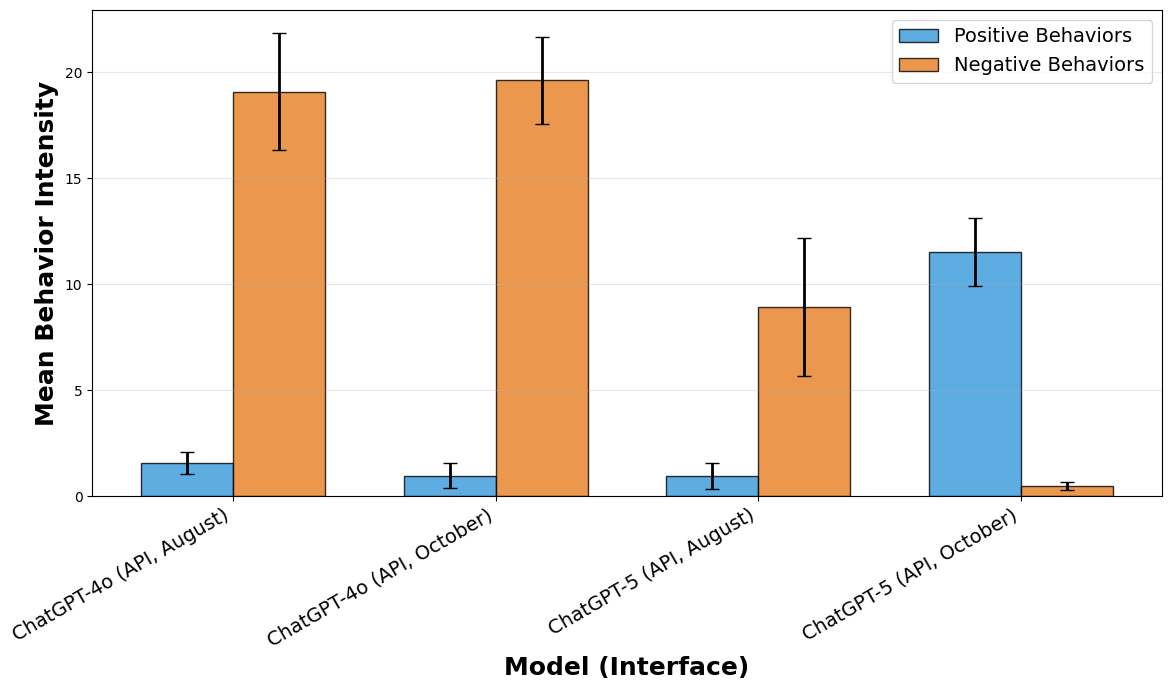

In [12]:
def plot_bar_comparison(df, grouping_label, turn_min=1, turn_max=20):
    """Plot bar chart comparing total positive vs negative behaviors with SE across conversations"""
    if df is None or len(df) == 0:
        print("No data to plot")
        return
    
    # Filter for specified turn range
    filtered_df = df[df['turn_index'].between(turn_min, turn_max)]
    
    # Get number of turns in the range
    n_turns = turn_max - turn_min + 1
    
    # Calculate average strength per turn for EACH conversation (scenario_id)
    # This gives us one data point per conversation
    conversation_stats = filtered_df.groupby(['scenario_id', 'model', 'behavior_category'])['strength'].sum().reset_index()
    conversation_stats['avg_strength_per_turn'] = conversation_stats['strength'] / n_turns
    
    # Now calculate mean and SE across conversations for each model/behavior combination
    stats_df = conversation_stats.groupby(['model', 'behavior_category'])['avg_strength_per_turn'].agg(['mean', 'std', 'count']).reset_index()
    stats_df['se'] = stats_df['std'] / np.sqrt(stats_df['count']) * 1.96
    
    # Pivot for plotting
    pivot_mean = stats_df.pivot(index='model', columns='behavior_category', values='mean').fillna(0)
    pivot_se = stats_df.pivot(index='model', columns='behavior_category', values='se').fillna(0)
    
    # Reorder models: API models on ends, CHAT models in middle
    # Separate CHAT and API models
    all_models = list(pivot_mean.index)
    chat_models = sorted([m for m in all_models if 'CHAT' in m])
    api_models = sorted([m for m in all_models if 'API' in m])
    
    # Order: First API, then CHAT models, then remaining API
    # For 2 CHAT and 2 API: API1, CHAT1, CHAT2, API2
    if len(api_models) == 2:
        model_order = [api_models[0]] + chat_models + [api_models[1]]
    else:
        # Fallback: put half API on left, CHAT in middle, half API on right
        mid_point = len(api_models) // 2
        model_order = api_models[:mid_point] + chat_models + api_models[mid_point:]
    
    # Reindex pivots with new order
    pivot_mean = pivot_mean.reindex(model_order)
    pivot_se = pivot_se.reindex(model_order)
    
    # Create bar plot
    fig, ax = plt.subplots(figsize=(12, 7))
    x = range(len(pivot_mean.index))
    width = 0.35
    
    # Plot bars with error bars
    bars1 = ax.bar([i - width/2 for i in x], pivot_mean['Positive Behaviors'],
                   width, label='Positive Behaviors', color='#3498db', alpha=0.8, 
                   edgecolor='black', yerr=pivot_se['Positive Behaviors'], 
                   capsize=5, error_kw={'linewidth': 2, 'ecolor': 'black'})
    bars2 = ax.bar([i + width/2 for i in x], pivot_mean['Negative Behaviors'],
                   width, label='Negative Behaviors', color='#e67e22', alpha=0.8, 
                   edgecolor='black', yerr=pivot_se['Negative Behaviors'],
                   capsize=5, error_kw={'linewidth': 2, 'ecolor': 'black'})
    
    # Customize plot
    n_convos = stats_df['count'].iloc[0]
    ax.set_xlabel('Model (Interface)', fontsize=18, fontweight='bold')
    ax.set_ylabel('Mean Behavior Intensity', fontsize=18, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(pivot_mean.index, rotation=30, ha='right', fontsize=14)
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Set y-axis to start at 0
    ax.set_ylim(bottom=0)
    
    # Add value labels on bars
    # for bars in [bars1, bars2]:
    #     for bar in bars:
    #         height = bar.get_height()
    #         if height > 0:
    #             ax.text(bar.get_x() + bar.get_width()/2., height,
    #                    f'{height:.1f}',
    #                    ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

plot_bar_comparison(df, grouping_label)